# PPO for Continuous Control: Pendulum

This notebook extends PPO from discrete actions (CartPole) to **continuous action spaces**
using a **Gaussian policy**. Pendulum-v1 is the "hello world" of continuous control —
the agent must apply a continuous torque to swing up and balance a pendulum.

We will:
1. Understand why discrete methods (DQN) fail on continuous action spaces
2. Replace the Categorical policy with a Gaussian (Normal) policy
3. Implement a `ContinuousActorCritic` with a learnable standard deviation
4. Train PPO on Pendulum-v1 and visualize the learned policy
5. Show how the policy's uncertainty (std) decreases as it learns

**Prerequisite:** Read the PPO CartPole notebook (02) first — this notebook assumes
familiarity with PPO's clipped objective, GAE, and the actor-critic architecture.

In [ ]:
import sys, os

# In Colab, clone the repo so local imports (src/) work
if "google.colab" in str(get_ipython()):
    if not os.path.exists("/content/DeepLearning_101"):
        !git clone --depth 1 https://github.com/MaxiRuess/DeepLearning_101.git /content/DeepLearning_101
    os.chdir("/content/DeepLearning_101/notebooks/04_Reinforcement_Learning")
    sys.path.insert(0, "/content/DeepLearning_101")
else:
    sys.path.insert(0, os.path.abspath('../..'))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import pygame
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from src.utils.device import set_seed
from src.models.ppo import RolloutBuffer

try:
    import gymnasium as gym
    print(f"Gymnasium version: {gym.__version__}")
except ImportError:
    print("Gymnasium not installed. Run: pip install -e '.[rl]'")

device = "cpu"
set_seed(42)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

## 1. Discrete vs Continuous Actions

| | CartPole (Discrete) | Pendulum (Continuous) |
|---|---|---|
| Actions | Push left (0) or right (1) | Torque in $[-2, 2]$ (any real number) |
| Policy output | Categorical: $P(a=0), P(a=1)$ | Gaussian: $\mu(s), \sigma$ |
| Action selection | Sample from 2 choices | Sample from $\mathcal{N}(\mu, \sigma^2)$ |
| DQN compatible? | Yes | **No** (infinite actions, can't compute $\max_a Q(s,a)$) |

DQN outputs a Q-value for each action and picks the max. With continuous actions,
there are infinitely many choices — you can't enumerate them. You could discretize
(e.g., 10 torque levels), but this loses precision and scales poorly with dimensions.

**Policy gradient methods handle continuous actions naturally** — they output a probability
distribution and sample from it.

## 2. Gaussian Policy

For continuous actions, the policy outputs a **Normal distribution**:

$\pi_\theta(a | s) = \mathcal{N}(a; \mu_\theta(s), \sigma^2)$

- **Mean $\mu_\theta(s)$**: a neural network that maps state to the expected action
- **Std $\sigma$**: controls exploration. Can be state-dependent or a learnable parameter.

**Log probability** (needed for the PPO objective):

$\log \pi(a|s) = -\frac{(a - \mu)^2}{2\sigma^2} - \log\sigma - \frac{1}{2}\log(2\pi)$

**Entropy** (for the exploration bonus):

$H[\pi] = \frac{1}{2}\log(2\pi e \sigma^2)$

Higher $\sigma$ = more exploration. As training progresses, $\sigma$ should decrease
as the policy becomes more confident about the optimal action.

In [17]:
# Explore the Pendulum-v1 environment
env = gym.make("Pendulum-v1")

print(f"State space: {env.observation_space}")
print(f"  Shape: {env.observation_space.shape}")
print(f"  State = [cos(theta), sin(theta), angular_velocity]")
print(f"\nAction space: {env.action_space}")
print(f"  Shape: {env.action_space.shape}")
print(f"  Low: {env.action_space.low}, High: {env.action_space.high}")
print(f"  Action = torque applied to the pendulum")

# Run a random episode
state, _ = env.reset(seed=42)
total_reward = 0
for step in range(200):
    action = env.action_space.sample()
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

print(f"\nRandom agent: {step+1} steps, total reward: {total_reward:.1f}")
print(f"Reward range: [{-16.27:.2f}, {0:.2f}] (always negative, goal is to minimize penalty)")
print(f"Reward = -(theta^2 + 0.1*angular_vel^2 + 0.001*torque^2)")
env.close()

State space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
  Shape: (3,)
  State = [cos(theta), sin(theta), angular_velocity]

Action space: Box(-2.0, 2.0, (1,), float32)
  Shape: (1,)
  Low: [-2.], High: [2.]
  Action = torque applied to the pendulum

Random agent: 200 steps, total reward: -1277.5
Reward range: [-16.27, 0.00] (always negative, goal is to minimize penalty)
Reward = -(theta^2 + 0.1*angular_vel^2 + 0.001*torque^2)


## 3. Continuous Actor-Critic Architecture

Same shared trunk as the discrete PPO, but the actor head outputs a **mean** instead of
logits, and `log_std` is a **learnable parameter** (not state-dependent):

```
State (3) → Shared(128 → ReLU → 128 → ReLU) → Mean head → μ (1)
                                               → Critic head → V(s) (1)
log_std: learnable parameter → σ = exp(log_std)
```

**Why `log_std` as a parameter?** It's the simplest approach for basic continuous control.
More advanced methods (SAC) make $\sigma$ state-dependent, but a global $\sigma$ works
well for Pendulum and is easier to understand.

In [18]:
class ContinuousActorCritic(nn.Module):
    """Actor-Critic for continuous action spaces using Gaussian policy.
    
    Uses SEPARATE networks for actor and critic to avoid competing gradients.
    """

    LOG_STD_MIN = -2.0   # σ min ≈ 0.14 — prevents collapse to zero exploration
    LOG_STD_MAX = 0.5    # σ max ≈ 1.65 — prevents explosion

    def __init__(self, state_size, action_size, hidden_size=256,
                 action_low=-2.0, action_high=2.0):
        super().__init__()
        self.action_low = action_low
        self.action_high = action_high

        # Separate actor network
        self.actor = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
        )
        self.mean_head = nn.Linear(hidden_size, action_size)

        # Separate critic network
        self.critic = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
        )
        self.critic_head = nn.Linear(hidden_size, 1)

        # Learnable log standard deviation
        self.log_std = nn.Parameter(torch.full((action_size,), -0.5))

        # Orthogonal initialization (standard for continuous PPO)
        for net in [self.actor, self.critic]:
            for layer in net:
                if isinstance(layer, nn.Linear):
                    nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                    nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.mean_head.weight, gain=0.01)
        nn.init.zeros_(self.mean_head.bias)
        nn.init.orthogonal_(self.critic_head.weight, gain=1.0)
        nn.init.zeros_(self.critic_head.bias)

    def forward(self, x):
        """Returns (mean, std, value)."""
        mean = self.mean_head(self.actor(x))
        # Clamp log_std to prevent std collapse or explosion
        log_std = torch.clamp(self.log_std, self.LOG_STD_MIN, self.LOG_STD_MAX)
        std = log_std.exp().expand_as(mean)
        value = self.critic_head(self.critic(x)).squeeze(-1)
        return mean, std, value

    def act(self, state):
        """Sample action from Gaussian, return (action, log_prob, value)."""
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, dtype=torch.float32)
        state = state.unsqueeze(0)

        with torch.no_grad():
            mean, std, value = self.forward(state)
            dist = Normal(mean, std)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum(-1)
            action = torch.clamp(action, self.action_low, self.action_high)

        return action.squeeze(0).numpy(), log_prob.item(), value.item()

    def evaluate(self, states, actions):
        """Evaluate actions: returns (log_probs, entropy, values)."""
        mean, std, values = self.forward(states)
        dist = Normal(mean, std)
        log_probs = dist.log_prob(actions).sum(-1)
        entropy = dist.entropy().sum(-1).mean()
        return log_probs, entropy, values


# Demo
ac = ContinuousActorCritic(state_size=3, action_size=1)
state = torch.randn(1, 3)
mean, std, value = ac(state)
print(f"Mean (μ): {mean.item():.4f}")
print(f"Std  (σ): {std.item():.4f}")
print(f"Value:    {value.item():.4f}")
print(f"log_std bounds: [{ac.LOG_STD_MIN}, {ac.LOG_STD_MAX}] → σ in [{np.exp(ac.LOG_STD_MIN):.2f}, {np.exp(ac.LOG_STD_MAX):.2f}]")

action, log_prob, val = ac.act(np.random.randn(3))
print(f"\nSampled action: {action} (clipped to [-2, 2])")
print(f"Parameters: {sum(p.numel() for p in ac.parameters()):,}")

Mean (μ): 0.0003
Std  (σ): 0.6065
Value:    -0.2167
log_std bounds: [-2.0, 0.5] → σ in [0.14, 1.65]

Sampled action: [0.88888884] (clipped to [-2, 2])
Parameters: 134,147


In [19]:
# Show how actions are sampled and clipped
ac_demo = ContinuousActorCritic(state_size=3, action_size=1)
state = torch.randn(3)

actions = []
for _ in range(1000):
    a, _, _ = ac_demo.act(state)
    actions.append(a[0])

print(f"1000 sampled actions from initial policy (std=1.0):")
print(f"  Mean: {np.mean(actions):.3f}")
print(f"  Std:  {np.std(actions):.3f}")
print(f"  Min:  {np.min(actions):.3f}, Max: {np.max(actions):.3f}")
print(f"  Clipped to [-2, 2]: {np.sum(np.abs(actions) >= 1.99) / len(actions) * 100:.1f}% at bounds")

1000 sampled actions from initial policy (std=1.0):
  Mean: -0.003
  Std:  0.616
  Min:  -2.000, Max: 1.807
  Clipped to [-2, 2]: 0.1% at bounds


## 4. What Changes from Discrete PPO?

Almost nothing! The only difference is the **distribution**:

| Component | Discrete (CartPole) | Continuous (Pendulum) |
|---|---|---|
| Distribution | `Categorical(logits)` | `Normal(mean, std)` |
| `log_prob` | `dist.log_prob(action)` | `dist.log_prob(action).sum(-1)` |
| Entropy | `dist.entropy()` | `dist.entropy().sum(-1)` |
| Action output | int | float array (clipped) |
| Buffer action dtype | `torch.long` | `torch.float32` |

The PPO objective (clipped surrogate), GAE, value loss, and training loop
are **identical**. The `RolloutBuffer` from notebook 02 works for both
(it auto-detects the action dtype).

In [20]:
class RunningMeanStd:
    """Track running mean/std for reward normalization."""
    def __init__(self):
        self.mean = 0.0
        self.var = 1.0
        self.count = 1e-4

    def update(self, x):
        batch_mean = np.mean(x)
        batch_var = np.var(x)
        batch_count = len(x)
        delta = batch_mean - self.mean
        total = self.count + batch_count
        self.mean += delta * batch_count / total
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        m2 = m_a + m_b + delta**2 * self.count * batch_count / total
        self.var = m2 / total
        self.count = total

    def normalize(self, x):
        return (x - self.mean) / (np.sqrt(self.var) + 1e-8)


class ContinuousPPOAgent:
    """PPO agent for continuous action spaces with reward normalization."""

    def __init__(self, state_size, action_size, hidden_size=64, lr=3e-4,
                 gamma=0.99, gae_lambda=0.95, clip_epsilon=0.2,
                 value_coeff=0.5, entropy_coeff=0.0, k_epochs=10,
                 batch_size=64, action_low=-2.0, action_high=2.0, device="cpu"):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.value_coeff = value_coeff
        self.entropy_coeff = entropy_coeff
        self.k_epochs = k_epochs
        self.batch_size = batch_size
        self.device = device

        self.ac = ContinuousActorCritic(
            state_size, action_size, hidden_size, action_low, action_high
        ).to(device)
        self.optimizer = optim.Adam(self.ac.parameters(), lr=lr, eps=1e-5)
        self.buffer = RolloutBuffer()
        self.reward_normalizer = RunningMeanStd()

        self.policy_losses = []
        self.value_losses = []
        self.entropies = []
        self.stds = []

    def select_action(self, state):
        return self.ac.act(state)

    def normalize_rewards(self):
        """Normalize rewards in-place before GAE computation."""
        raw_rewards = np.array(self.buffer.rewards)
        self.reward_normalizer.update(raw_rewards)
        normalized = self.reward_normalizer.normalize(raw_rewards)
        self.buffer.rewards = normalized.tolist()

    def update(self):
        """Run K epochs of PPO updates on the current rollout."""
        self.stds.append(self.ac.log_std.exp().mean().item())

        for _ in range(self.k_epochs):
            for batch in self.buffer.get_batches(self.batch_size, self.device):
                states = batch["states"]
                actions = batch["actions"]
                old_log_probs = batch["old_log_probs"]
                returns = batch["returns"]
                advantages = batch["advantages"]

                new_log_probs, entropy, values = self.ac.evaluate(states, actions)

                ratio = torch.exp(new_log_probs - old_log_probs)

                surr1 = ratio * advantages
                surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon,
                                    1.0 + self.clip_epsilon) * advantages
                policy_loss = -torch.min(surr1, surr2).mean()

                value_loss = nn.functional.mse_loss(values, returns)

                loss = policy_loss + self.value_coeff * value_loss - self.entropy_coeff * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.ac.parameters(), 0.5)
                self.optimizer.step()

                self.policy_losses.append(policy_loss.item())
                self.value_losses.append(value_loss.item())
                self.entropies.append(entropy.item())

        self.buffer.clear()


print("ContinuousPPOAgent ready.")

ContinuousPPOAgent ready.


In [21]:
def train_ppo_continuous(agent, env, num_updates=300, rollout_length=2048, print_every=30):
    """Train a continuous PPO agent and return episode rewards."""
    rewards_history = []
    state, _ = env.reset()
    episode_reward = 0

    for update in range(num_updates):
        for _ in range(rollout_length):
            action, log_prob, value = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.buffer.push(state, action, reward, value, log_prob, float(done))
            state = next_state
            episode_reward += reward

            if done:
                rewards_history.append(episode_reward)
                episode_reward = 0
                state, _ = env.reset()

        # CRITICAL: normalize rewards BEFORE computing GAE advantages
        agent.normalize_rewards()

        # Now compute advantages on normalized rewards
        with torch.no_grad():
            _, _, last_value = agent.select_action(state)
        agent.buffer.compute_returns_and_advantages(
            last_value, agent.gamma, agent.gae_lambda
        )

        agent.update()

        if (update + 1) % print_every == 0 and rewards_history:
            recent = rewards_history[-20:] if len(rewards_history) >= 20 else rewards_history
            std = agent.ac.log_std.exp().item()
            print(f"Update {update+1:4d} | Episodes: {len(rewards_history):4d} | "
                  f"Avg reward: {np.mean(recent):8.1f} | Std: {std:.3f}")

    return rewards_history


print("Training function ready.")

Training function ready.


## 5. Reward Structure

Pendulum-v1 reward: $r = -(\theta^2 + 0.1 \dot{\theta}^2 + 0.001 a^2)$

- $\theta$: angle from upright (0 = upright)
- $\dot{\theta}$: angular velocity (0 = still)
- $a$: torque applied (small is better)

The reward is **always negative** — the goal is to minimize the penalty.
Best possible: $r \approx 0$ (upright, still, no torque).
Worst: $r \approx -16.3$ (hanging down, spinning fast).

Unlike CartPole's sparse $+1$ per step, Pendulum has a **dense, shaped reward**
that provides gradient signal at every timestep.

## 6. Training

**Hyperparameters:**

| Parameter | Value | Notes |
|---|---|---|
| Hidden size | 64 | Smaller network with Tanh activations |
| Rollout length | 2048 | Timesteps per rollout |
| K epochs | 10 | Gradient steps per rollout |
| Clip $\epsilon$ | 0.2 | Same as CartPole |
| $\gamma$ | 0.99 | Discount factor |
| GAE $\lambda$ | 0.95 | Advantage smoothing |
| Learning rate | $3 \times 10^{-4}$ | Adam optimizer |
| Entropy coeff | 0.0 | Disabled — Gaussian entropy bonus can destabilize continuous control |
| Reward normalization | Running mean/std | Critical for Pendulum's large negative rewards |
| Weight init | Orthogonal | Standard for continuous PPO (stabilizes training) |
| Initial $\sigma$ | 0.5 | `log_std = -0.7` → moderate exploration |

In [22]:
set_seed(42)
random.seed(42)
np.random.seed(42)

env = gym.make("Pendulum-v1")

agent = ContinuousPPOAgent(
    state_size=3,
    action_size=1,
    hidden_size=256,
    lr=3e-4,               # back to standard — 1e-3 was too aggressive
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    value_coeff=0.5,
    entropy_coeff=0.0,
    k_epochs=10,
    batch_size=64,
    action_low=-2.0,
    action_high=2.0,
    device=device,
)

print("Training PPO on Pendulum-v1 (continuous control)...\n")
rewards = train_ppo_continuous(
    agent, env, num_updates=500, rollout_length=4096, print_every=50
)

env.close()
print(f"\nTotal episodes: {len(rewards)}")
print(f"Final avg reward (last 50): {np.mean(rewards[-50:]):.1f}")
print(f"Final std: {agent.ac.log_std.exp().item():.4f}")

Set seed for reproducibility: 42
Training PPO on Pendulum-v1 (continuous control)...

Update   50 | Episodes: 1024 | Avg reward:   -508.5 | Std: 0.343
Update  100 | Episodes: 2048 | Avg reward:   -260.7 | Std: 0.218
Update  150 | Episodes: 3072 | Avg reward:   -269.1 | Std: 0.178
Update  200 | Episodes: 4096 | Avg reward:   -215.3 | Std: 0.151
Update  250 | Episodes: 5120 | Avg reward:   -543.1 | Std: 0.135
Update  300 | Episodes: 6144 | Avg reward:  -1194.3 | Std: 0.135
Update  350 | Episodes: 7168 | Avg reward:   -689.9 | Std: 0.135
Update  400 | Episodes: 8192 | Avg reward:   -415.5 | Std: 0.135
Update  450 | Episodes: 9216 | Avg reward:   -356.9 | Std: 0.135
Update  500 | Episodes: 10240 | Avg reward:   -278.3 | Std: 0.135

Total episodes: 10240
Final avg reward (last 50): -267.6
Final std: 0.1352


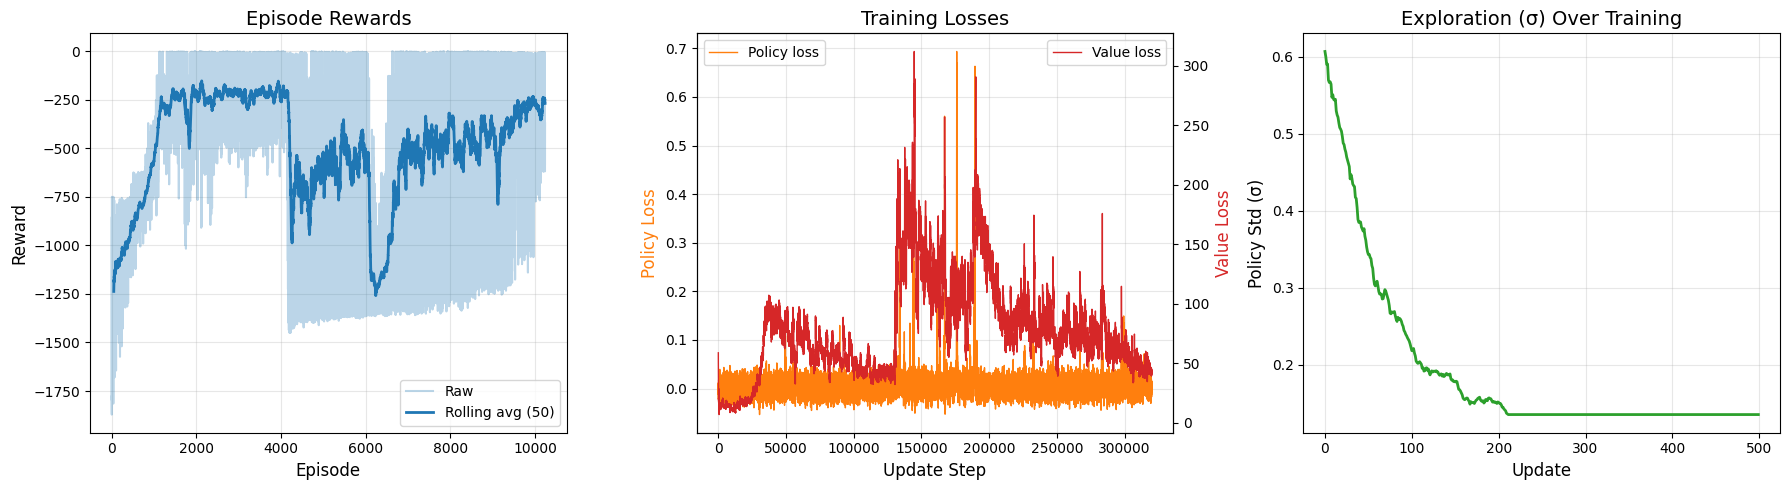

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Episode Rewards
ax = axes[0]
ax.plot(rewards, alpha=0.3, color='tab:blue', label='Raw')
window = 50
rolling = pd.Series(rewards).rolling(window=window).mean()
ax.plot(rolling, color='tab:blue', linewidth=2, label=f'Rolling avg ({window})')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Episode Rewards', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Policy Loss and Value Loss
ax = axes[1]
if agent.policy_losses:
    ax.plot(pd.Series(agent.policy_losses).rolling(50).mean(),
            color='tab:orange', linewidth=1, label='Policy loss')
    ax2 = ax.twinx()
    ax2.plot(pd.Series(agent.value_losses).rolling(50).mean(),
             color='tab:red', linewidth=1, label='Value loss')
    ax2.set_ylabel('Value Loss', fontsize=12, color='tab:red')
    ax2.legend(loc='upper right', fontsize=10)
ax.set_xlabel('Update Step', fontsize=12)
ax.set_ylabel('Policy Loss', fontsize=12, color='tab:orange')
ax.set_title('Training Losses', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Standard Deviation over Training
ax = axes[2]
if agent.stds:
    ax.plot(agent.stds, color='tab:green', linewidth=2)
ax.set_xlabel('Update', fontsize=12)
ax.set_ylabel('Policy Std (σ)', fontsize=12)
ax.set_title('Exploration (σ) Over Training', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Evaluate the trained agent (deterministic: use mean action, no sampling)
eval_env = gym.make("Pendulum-v1")
eval_rewards = []

for ep in range(10):
    state, _ = eval_env.reset(seed=ep)
    episode_reward = 0
    done = False
    while not done:
        # Deterministic: use mean action directly (no sampling)
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            mean, _, _ = agent.ac(state_t)
            action = torch.clamp(mean, -2.0, 2.0).squeeze(0).numpy()
        state, reward, terminated, truncated, _ = eval_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    eval_rewards.append(episode_reward)
    print(f"Eval episode {ep+1}: reward = {episode_reward:.1f}")

eval_env.close()
print(f"\nAvg eval reward: {np.mean(eval_rewards):.1f}")
print(f"(Best possible ≈ -200, random ≈ -1500)")

Eval episode 1: reward = -129.7
Eval episode 2: reward = -128.7
Eval episode 3: reward = -126.2
Eval episode 4: reward = -360.3
Eval episode 5: reward = -501.8
Eval episode 6: reward = -244.0
Eval episode 7: reward = -4.6
Eval episode 8: reward = -127.9
Eval episode 9: reward = -130.4
Eval episode 10: reward = -251.1

Avg eval reward: -200.5
(Best possible ≈ -200, random ≈ -1500)


In [25]:
# Visualize the trained agent playing Pendulum
from matplotlib import animation
from IPython.display import HTML

render_env = gym.make("Pendulum-v1", render_mode="rgb_array")
state, _ = render_env.reset(seed=0)
frames = []
done = False

while not done:
    frames.append(render_env.render())
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        mean, _, _ = agent.ac(state_t)
        action = torch.clamp(mean, -2.0, 2.0).squeeze(0).numpy()
    state, reward, terminated, truncated, _ = render_env.step(action)
    done = terminated or truncated

render_env.close()
print(f"Recorded {len(frames)} frames")

# Animate
fig, ax = plt.subplots(figsize=(4, 4))
ax.axis("off")
img = ax.imshow(frames[0])

def update(frame):
    img.set_data(frames[frame])
    return [img]

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=20, blit=True)
plt.close(fig)
HTML(anim.to_html5_video())

Recorded 200 frames


## 7. Interpreting the Standard Deviation

The policy's $\sigma$ tells us about the agent's **confidence**:

- **High $\sigma$ (early training):** Wide Gaussian → explores many different torque values
- **Low $\sigma$ (late training):** Narrow Gaussian → confidently applies the right torque

This is analogous to $\epsilon$-decay in DQN, but learned automatically instead of
following a fixed schedule.

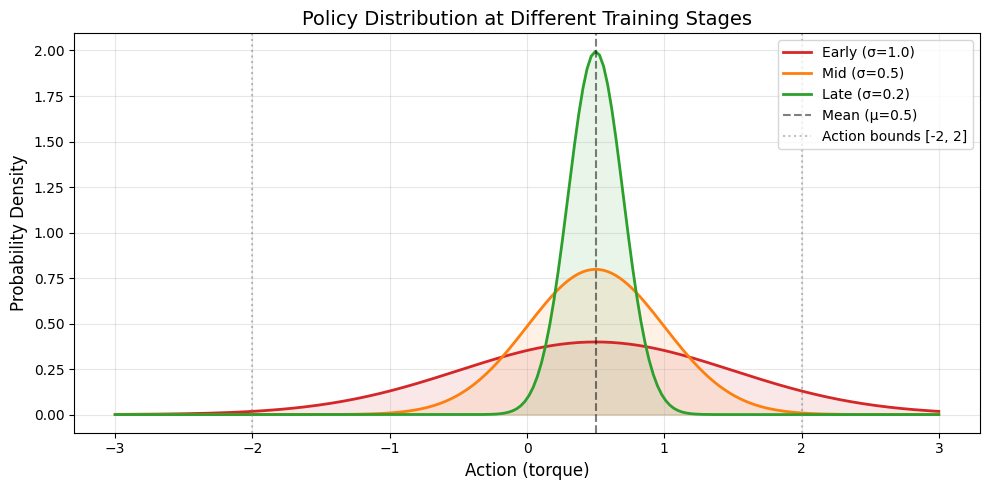

In [11]:
# Visualize the action distribution at different training stages
fig, ax = plt.subplots(figsize=(10, 5))

x = np.linspace(-3, 3, 200)

# Simulate different std values from training
std_values = [
    (1.0, 'Early (σ=1.0)', 'tab:red'),
    (0.5, 'Mid (σ=0.5)', 'tab:orange'),
    (0.2, 'Late (σ=0.2)', 'tab:green'),
]

mean = 0.5  # Example: optimal action for some state

for std, label, color in std_values:
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    ax.plot(x, pdf, label=label, color=color, linewidth=2)
    ax.fill_between(x, pdf, alpha=0.1, color=color)

ax.axvline(x=mean, color='black', linestyle='--', alpha=0.5, label=f'Mean (μ={mean})')
ax.axvline(x=-2, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=2, color='gray', linestyle=':', alpha=0.5, label='Action bounds [-2, 2]')
ax.set_xlabel('Action (torque)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Policy Distribution at Different Training Stages', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Discrete vs Continuous PPO Summary

| | Discrete PPO (CartPole) | Continuous PPO (Pendulum) |
|---|---|---|
| Distribution | Categorical | Normal (Gaussian) |
| Actor output | Logits (K values) | Mean μ (D values) |
| Exploration | Entropy of categorical | Entropy of Gaussian (via σ) |
| σ (exploration) | N/A | Learned parameter, decreases over training |
| PPO objective | Identical | Identical |
| GAE | Identical | Identical |
| Value network | Identical | Identical |
| RolloutBuffer | Identical | Identical (auto-detects action dtype) |

## 9. Reusable Implementation

The `ContinuousActorCritic` is available in `src/models/ppo.py`:

```python
from src.models.ppo import ContinuousActorCritic, RolloutBuffer
```

In [ ]:
from src.models.ppo import ContinuousActorCritic as CAC, RolloutBuffer as RB

ac_test = CAC(state_size=3, action_size=1)
mean, std, value = ac_test(torch.randn(1, 3))
print(f"ContinuousActorCritic: mean={mean.shape}, std={std.shape}, value={value.shape}")

action, lp, v = ac_test.act(np.random.randn(3))
print(f"Action: {action}, clipped to [-2, 2]: {np.all(np.abs(action) <= 2)}")
print("All src/ imports verified.")

## 10. Key Takeaways

1. **Continuous actions use a Gaussian policy.** The network outputs $\mu(s)$, and actions are sampled from $\mathcal{N}(\mu, \sigma^2)$. This naturally handles infinite action spaces.

2. **$\sigma$ controls the exploration-exploitation tradeoff.** It starts high (explore) and decreases as training progresses (exploit). Unlike $\epsilon$-decay in DQN, this is **learned** — the optimizer adjusts $\sigma$ automatically.

3. **The PPO objective is identical for discrete and continuous.** Only the distribution changes (Categorical → Normal). Clipping, GAE, value loss, and entropy bonus work the same way.

4. **Continuous control is harder than discrete.** Pendulum needs more training steps, more epochs per update, and is sensitive to hyperparameters. This is typical for continuous control tasks.

5. **Applications of continuous PPO:** Robotics (joint torques), autonomous driving (steering/throttle), finance (portfolio allocation), game AI (continuous movement).

### Further Reading

- Schulman et al. (2017). *Proximal Policy Optimization Algorithms.* https://arxiv.org/abs/1707.06347
- Haarnoja et al. (2018). *Soft Actor-Critic (SAC).* https://arxiv.org/abs/1801.01290 — state-dependent std, maximum entropy RL
- OpenAI Spinning Up: https://spinningup.openai.com/